In [26]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate, train_test_split

from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
RANDOM_STATE = 54
np.random.seed(RANDOM_STATE)
np.set_printoptions(precision=6, suppress=True, formatter={'all': lambda x: f'{x:0.6f}'})

1) ML-решение - на ваше усмотрение + 2 балла. Топ-5 получат +1 балл

2) Попробовать фильтровать сигнал, чтобы искать качественные высокоуровневые фичи. По фичам построить пороговый классификатор,
сравнить его с ML-решением.
+ Попробовать фильтровать сигнал при помощи рекуррентных фильтров. + 1 балл
+ Попробовать фильтровать сигнал при помощи сверточные оконные фильтры (np.convolve или torch.conv). + 1 балл
+ Попробовать фильтровать сигнал при помощи преобразования Фурье. + 1 балл

   Каждым из способов попробовать извлечь фичи, посмотреть точность.

In [28]:
label2idx = {"Normal": 0, "MI": 1}
idx2label = {0: "Normal", 1: "MI"}

data = pd.read_csv('PPG_Dataset.csv')
labels = data['Label']
data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,1991,1992,1993,1994,1995,1996,1997,1998,1999,Label
0,-0.015552,0.016963,0.013575,0.027204,0.068154,0.129259,0.127915,0.345174,0.197811,0.167651,...,-0.426464,-0.346976,-0.132168,-0.252098,-0.241969,-0.134235,-0.091327,-0.081713,-0.057693,MI
1,0.002323,0.002754,0.022539,0.228807,0.107751,0.034439,0.086007,0.155667,0.163327,0.223759,...,-0.169345,-0.356808,-0.338996,-0.292489,-0.152872,-0.156076,-0.103265,-0.041579,-0.044272,MI
2,0.050481,-0.339781,0.265111,0.045092,0.040086,0.087173,0.092814,0.099586,-0.143305,0.164186,...,-0.401426,-0.402333,-0.373426,-0.303710,0.008599,-0.180633,-0.143135,-0.084758,0.060668,MI
3,0.023882,0.016561,0.248547,0.054567,0.128032,0.085954,0.107359,0.207137,0.174547,-0.100118,...,-0.390700,-0.353882,-0.294014,-0.267005,-0.242258,-0.186946,-0.173718,0.101331,0.063555,MI
4,-0.058591,0.171551,0.057262,0.270869,0.138357,0.078509,0.062504,0.104447,0.134795,0.194248,...,-0.391598,-0.334490,-0.326873,-0.249881,-0.210052,-0.194763,-0.415365,0.015432,0.010321,MI


In [29]:
X = data.drop('Label', axis=1).to_numpy()
y = labels.map(label2idx)

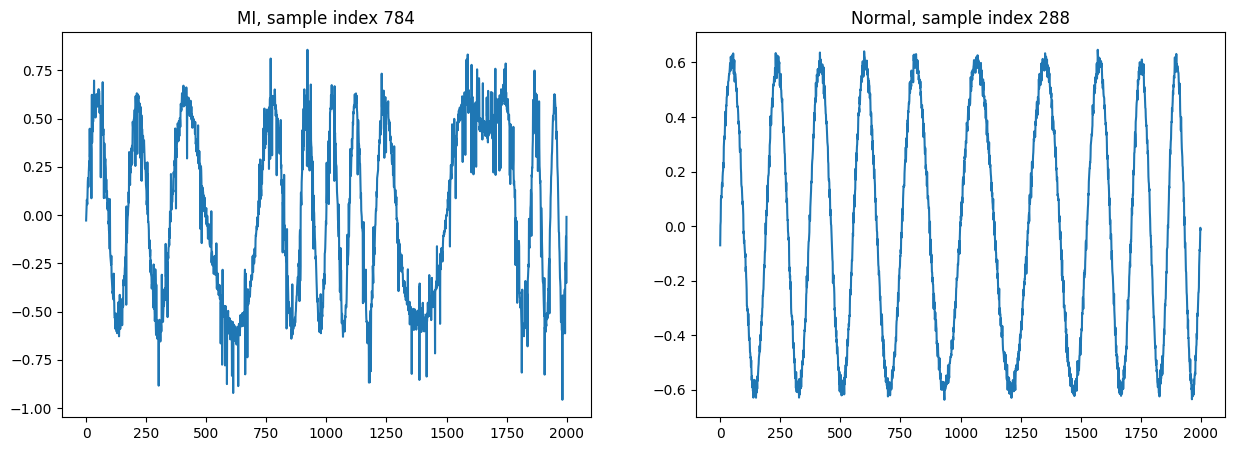

In [30]:
#Закрепим два семпла под графики
mi_ppg_example_idx = data[data['Label'] == 'MI'].sample(n=1).index.values.item()
normal_ppg_example_idx = data[data['Label'] == 'Normal'].sample(n=1).index.values.item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(X[mi_ppg_example_idx]);
ax1.set_title(f"MI, sample index {mi_ppg_example_idx}")

ax2.plot(X[normal_ppg_example_idx]);
ax2.set_title(f"Normal, sample index {normal_ppg_example_idx}");

In [31]:
def extract_features(series):
    return np.array([
        np.mean(series),
        np.std(series),
        np.max(series),
        np.min(series),
        np.max(series) - np.min(series),
        np.polyfit(np.arange(len(series)), series, 1)[0],
        pd.Series(series).skew(),
        pd.Series(series).kurt()
    ])

## ML Baseline (base features + Random Forest)

In [32]:
features = [extract_features(series) for series in X]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=RANDOM_STATE)

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=54)

In [35]:
y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"F1-score: {f1_score(y_test, y_pred):.5f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.5f}")

Accuracy: 0.96507
F1-score: 0.96356
ROC AUC: 0.96466


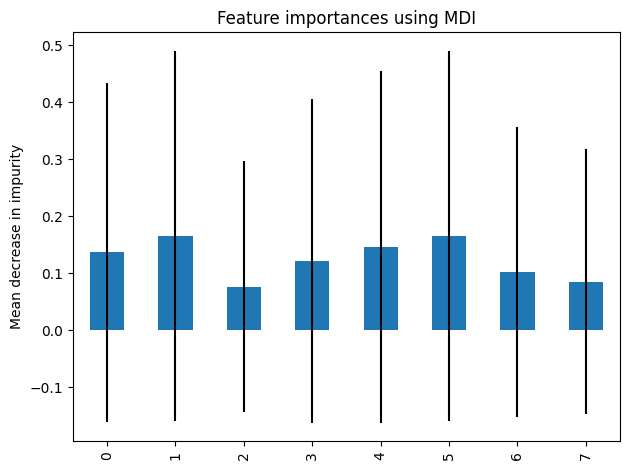

In [36]:
forest_importances = pd.Series(rf.feature_importances_)
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [37]:
#cross-validation results
results = cross_validate(rf, features, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'])
df = pd.DataFrame([results['test_accuracy'], results['test_f1'], results['test_roc_auc']])
df = df.rename(index={0: 'Accuracy', 1: 'F1', 2: 'ROC_AUC'})
df

,0,1,2,3,4
Accuracy,0.899225,1.0,1.0,1.0,0.922330
F1,0.897638,1.0,1.0,1.0,0.920319
ROC_AUC,0.913150,1.0,1.0,1.0,0.937193


In [38]:
class ThresholdClassifier:
    def __init__(self, vote_threshold=4):
        self.thresholds = None
        self.vote_threshold = vote_threshold
        
    def fit(self, X, y):
        self.thresholds = []
        for i in tqdm(range(X.shape[1])):
            best_thresh = 0
            best_j = -np.inf
            values = X[:, i]
            
            candidates = np.unique(values)
            for candidate in candidates:
                y_pred = (values >= candidate).astype(int)
                tp = np.sum((y_pred == 1) & (y == 1))
                fp = np.sum((y_pred == 1) & (y == 0))
                tn = np.sum((y_pred == 0) & (y == 0))
                fn = np.sum((y_pred == 0) & (y == 1))
                
                # Метод Йодена: J = Sensitivity + Specificity - 1
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                j = sensitivity + specificity - 1
                
                if j > best_j:
                    best_j = j
                    best_thresh = candidate
                    
            self.thresholds.append(best_thresh)
            
    def predict(self, X):
        if self.thresholds is None:
            raise ValueError("Сначала вызовите find_best_thresholds()")
            
        votes = np.zeros(X.shape[0])
        for i in range(X.shape[1]):
            votes += (X[:, i] >= self.thresholds[i]).astype(int)
            
        return (votes >= self.vote_threshold).astype(int)
            
    def load_thresholds(self, path):
        self.thresholds = np.load(path)
        
    def save_thresholds(self, path):
        np.save(path, self.thresholds)

## Recurrent filters

In [51]:
from scipy.signal import butter, filtfilt

def recursive_filter(signal, cutoff=5, fs=100, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered = filtfilt(b, a, signal)
    return filtered

filtered_recursive_data = np.array([recursive_filter(series) for series in X])
filtered_recursive_features = np.array([extract_features(series) for series in filtered_recursive_data])

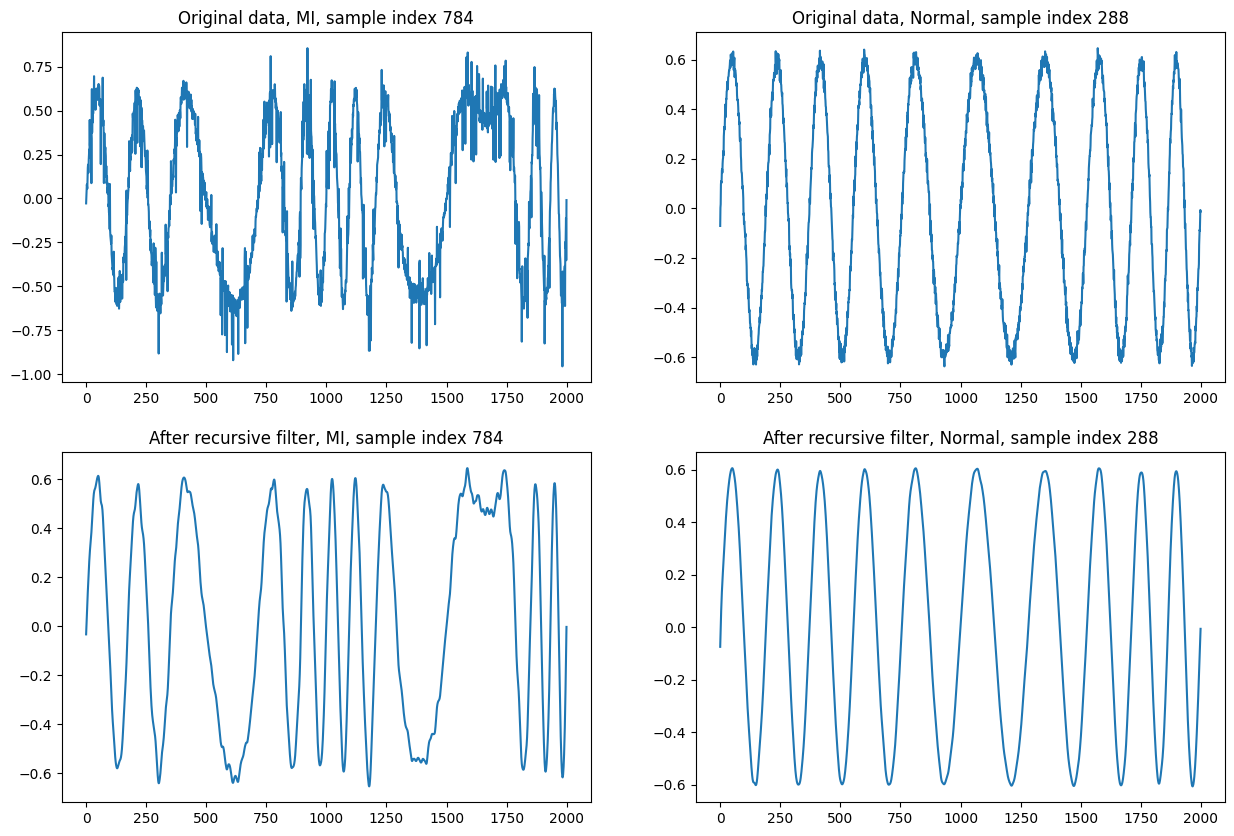

In [52]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(X[mi_ppg_example_idx]);
ax1.set_title(f"Original data, MI, sample index {mi_ppg_example_idx}")

ax2.plot(X[normal_ppg_example_idx]);
ax2.set_title(f"Original data, Normal, sample index {normal_ppg_example_idx}");

ax3.plot(filtered_recursive_data[mi_ppg_example_idx]);
ax3.set_title(f"After recursive filter, MI, sample index {mi_ppg_example_idx}")

ax4.plot(filtered_recursive_data[normal_ppg_example_idx]);
ax4.set_title(f"After recursive filter, Normal, sample index {normal_ppg_example_idx}");

In [53]:
X_train, X_test, y_train, y_test = train_test_split(filtered_recursive_features, y, test_size=0.3, random_state=RANDOM_STATE)

In [54]:
recursive_clf = ThresholdClassifier(vote_threshold=4)
recursive_clf.fit(X_train, y_train)

y_pred = recursive_clf.predict(X_test)

print(f"Пороги для признаков: {np.array(recursive_clf.thresholds)}\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"F1-score: {f1_score(y_test, y_pred):.5f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.5f}")

100%|██████████| 8/8 [00:05<00:00,  1.57it/s]

Пороги для признаков: [0.010610 0.426537 0.617810 -0.736135 1.234839 0.000038 -0.005941
 -1.574105]

Accuracy: 0.96507
F1-score: 0.96356
ROC AUC: 0.96466


## Conv filters

In [55]:
def window_filter(signal, window_size=5):
    kernel = np.ones(window_size) / window_size
    return np.convolve(signal, kernel, mode='same')

filtered_conv_data = np.array([window_filter(series) for series in X])
filtered_conv_features = np.array([extract_features(series) for series in filtered_conv_data])

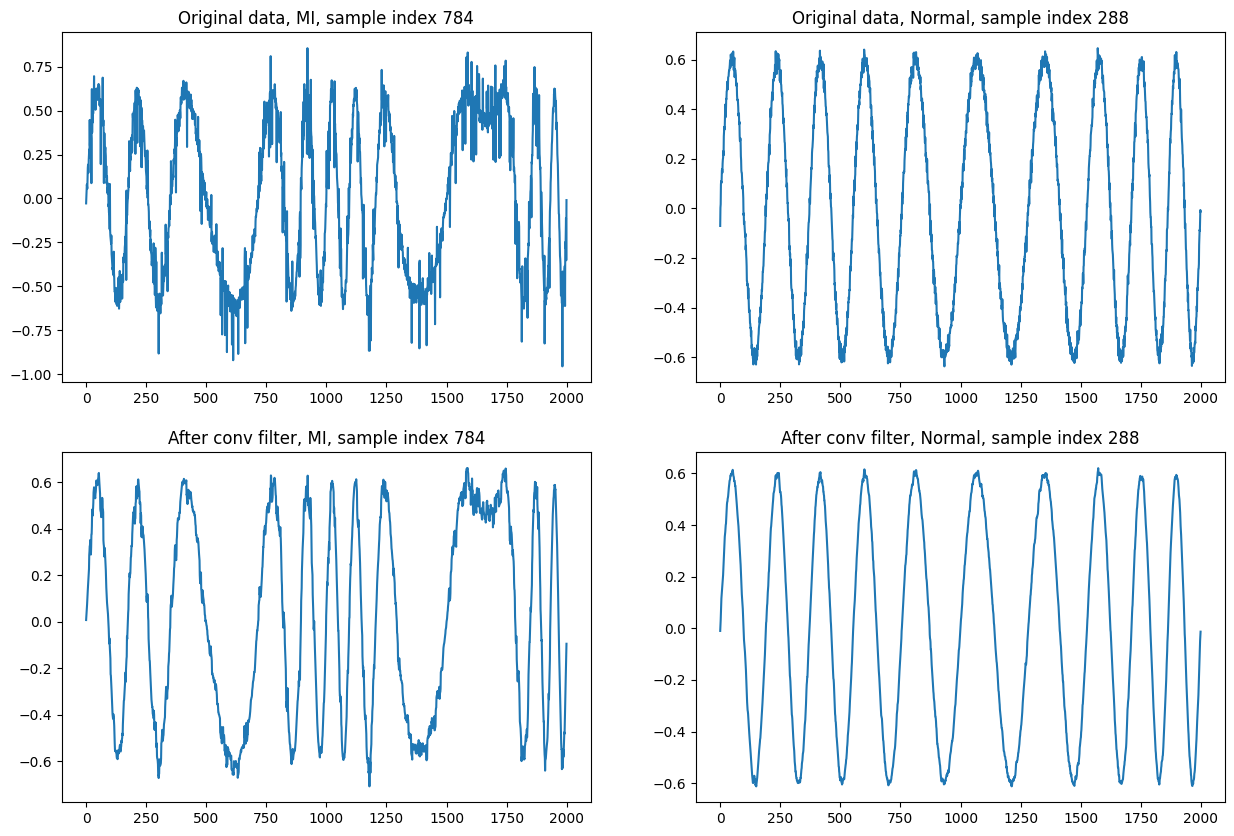

In [56]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(X[mi_ppg_example_idx]);
ax1.set_title(f"Original data, MI, sample index {mi_ppg_example_idx}")

ax2.plot(X[normal_ppg_example_idx]);
ax2.set_title(f"Original data, Normal, sample index {normal_ppg_example_idx}");

ax3.plot(filtered_conv_data[mi_ppg_example_idx]);
ax3.set_title(f"After conv filter, MI, sample index {mi_ppg_example_idx}")

ax4.plot(filtered_conv_data[normal_ppg_example_idx]);
ax4.set_title(f"After conv filter, Normal, sample index {normal_ppg_example_idx}");

In [57]:
X_train, X_test, y_train, y_test = train_test_split(filtered_conv_features, y, test_size=0.3, random_state=RANDOM_STATE)

In [58]:
conv_clf = ThresholdClassifier(vote_threshold=4)
conv_clf.fit(X_train, y_train)

y_pred = conv_clf.predict(X_test)

print(f"Пороги для признаков: {np.array(conv_clf.thresholds)}\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"F1-score: {f1_score(y_test, y_pred):.5f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.5f}")

100%|██████████| 8/8 [00:05<00:00,  1.56it/s]

Пороги для признаков: [0.010579 0.427152 0.636975 -0.607198 1.302004 0.000038 -0.005881
 -1.560785]

Accuracy: 0.96507
F1-score: 0.96356
ROC AUC: 0.96466


## Fourier transform

In [47]:
def fourier_filter(signal, threshold=0.1):
    fft = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(len(signal))
    fft[np.abs(frequencies) > threshold] = 0 
    filtered = np.fft.ifft(fft).real
    return filtered

filtered_fourier_data = np.array([fourier_filter(series) for series in X])
filtered_fourier_features = np.array([extract_features(series) for series in filtered_fourier_data])

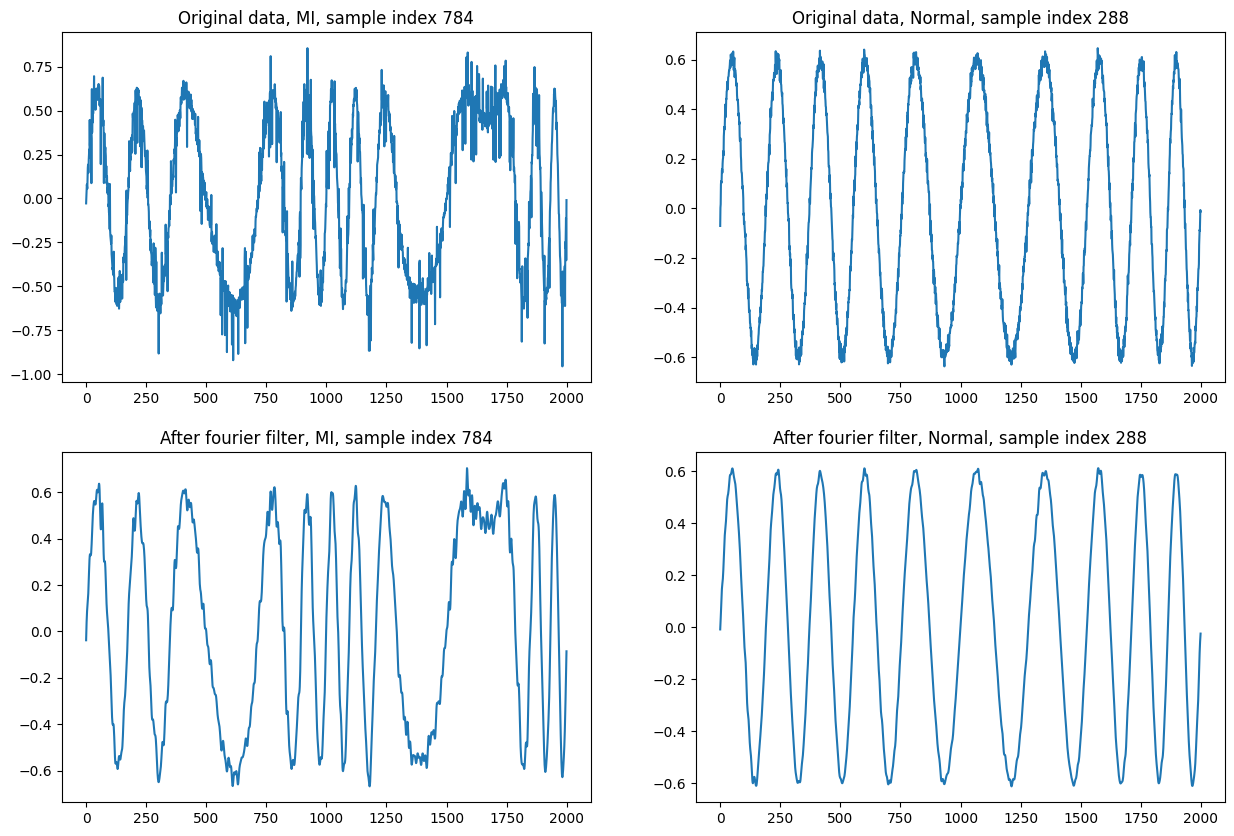

In [48]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(X[mi_ppg_example_idx]);
ax1.set_title(f"Original data, MI, sample index {mi_ppg_example_idx}")

ax2.plot(X[normal_ppg_example_idx]);
ax2.set_title(f"Original data, Normal, sample index {normal_ppg_example_idx}");

ax3.plot(filtered_fourier_data[mi_ppg_example_idx]);
ax3.set_title(f"After fourier filter, MI, sample index {mi_ppg_example_idx}")

ax4.plot(filtered_fourier_data[normal_ppg_example_idx]);
ax4.set_title(f"After fourier filter, Normal, sample index {normal_ppg_example_idx}");

In [49]:
X_train, X_test, y_train, y_test = train_test_split(filtered_fourier_features, y, test_size=0.3, random_state=RANDOM_STATE)

In [50]:
filtered_clf = ThresholdClassifier(vote_threshold=4)
filtered_clf.fit(X_train, y_train)

y_pred = filtered_clf.predict(X_test)

print(f"Пороги для признаков: {np.array(filtered_clf.thresholds)}\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"F1-score: {f1_score(y_test, y_pred):.5f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.5f}")

100%|██████████| 8/8 [00:05<00:00,  1.50it/s]

Пороги для признаков: [0.010573 0.427842 0.635625 -0.820946 1.303307 0.000038 -0.005877
 -1.562851]

Accuracy: 0.96507
F1-score: 0.96356
ROC AUC: 0.96466


### Все методы показывают одинаковые метрики качества на выделенной тестовой выборке:

### Accuracy: 0.96507 <br>
### F1-score: 0.96356 <br>
### ROC AUC: 0.96466 

### Трешхолды на фичах отличаются, но только с 3-4 знака после запятой 